# L9d Lab: Predictive Maintenance on the UCI AI4I Dataset

> **Learning objectives**
>
> - Separate identifiers, permissible features, and target columns.
> - Prevent target leakage by excluding the five failure-mode targets.
> - Make a reproducible stratified split and fit scaling on training data only.
> - Compare perceptron and logistic models with a majority baseline.
> - Explain missed-failure versus false-alarm tradeoffs.


## Setup and attributed source data


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


In [2]:
frame = load_ai4i(joinpath(CHEME5800_L9D_DATA, "ai4i2020.csv"))
data = prepare_ai4i(frame)
(failures = sum(data.y), observations = length(data.y), features = data.feature_names)


(failures = 339, observations = 10000, features = ["air_temperature", "process_temperature", "rotational_speed", "torque", "tool_wear", "type_M", "type_H"])

The input matrix contains five process measurements and two product-type indicators. It deliberately excludes `UDI`, `Product ID`, and the failure-mode columns `TWF`, `HDF`, `PWF`, `OSF`, and `RNF`. Those mode columns directly determine the target and would leak the answer.


In [3]:
split = stratified_split(data.y; train_fraction = 0.8, seed = 5800)
scaled = standardize_from_training(data.X[split.train, :], data.X[split.test, :])
y_train, y_test = data.y[split.train], data.y[split.test]

perceptron = fit_perceptron(scaled.train, y_train)
logistic = fit_logistic(scaled.train, y_train)

perceptron_metrics = classification_metrics(y_test, predict_perceptron(perceptron, scaled.test))
logistic_prediction = predict_logistic(logistic, scaled.test)
logistic_metrics = classification_metrics(y_test, logistic_prediction.labels)
majority_metrics = classification_metrics(y_test, zeros(Int, length(y_test)))

comparison = DataFrame(
    model = ["majority", "perceptron", "weighted logistic"],
    accuracy = [majority_metrics.accuracy, perceptron_metrics.accuracy, logistic_metrics.accuracy],
    precision = [majority_metrics.precision, perceptron_metrics.precision, logistic_metrics.precision],
    recall = [majority_metrics.recall, perceptron_metrics.recall, logistic_metrics.recall],
    false_positives = [majority_metrics.fp, perceptron_metrics.fp, logistic_metrics.fp],
    false_negatives = [majority_metrics.fn, perceptron_metrics.fn, logistic_metrics.fn],
)
pretty_table(comparison)


┌───────────────────┬──────────┬───────────┬──────────┬─────────────────┬───────
│             model │ accuracy │ precision │   recall │ false_positives │ fals ⋯
│            String │  Float64 │   Float64 │  Float64 │           Int64 │      ⋯
├───────────────────┼──────────┼───────────┼──────────┼─────────────────┼───────
│          majority │ 0.966017 │       0.0 │      0.0 │               0 │      ⋯
│        perceptron │  0.75912 │  0.103448 │ 0.794118 │             468 │      ⋯
│ weighted logistic │ 0.818591 │  0.130326 │ 0.764706 │             347 │      ⋯
└───────────────────┴──────────┴───────────┴──────────┴─────────────────┴───────
                                                                1 column omitted


In [4]:
@test length(split.train) + length(split.test) == 10_000
@test maximum(abs, mean(scaled.train; dims = 1)) < 1e-10
@test majority_metrics.accuracy > logistic_metrics.accuracy
@test majority_metrics.recall == 0.0
@test logistic_metrics.recall > 0.70
@test last(logistic.losses) < first(logistic.losses)
:ai4i_classification_verified


:ai4i_classification_verified

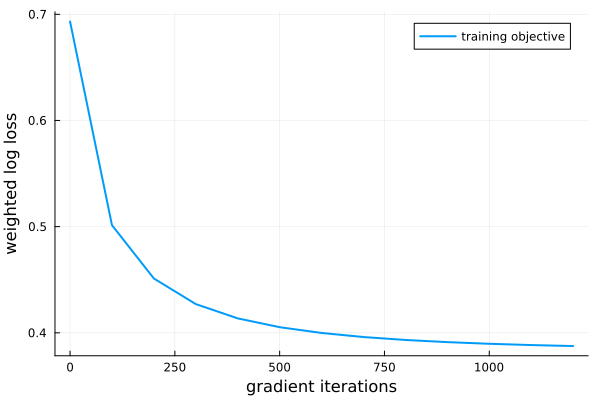

In [5]:
plot(0:100:(100*(length(logistic.losses)-1)), logistic.losses; lw = 2, xlabel = "gradient iterations", ylabel = "weighted log loss", label = "training objective")


## Interpretation

The majority classifier has the highest accuracy because failures are rare, but it detects none. Class weighting substantially improves recall at the cost of false alarms. The acceptable operating point depends on inspection cost, downtime, safety, and the consequence of a missed failure—not on accuracy alone.
